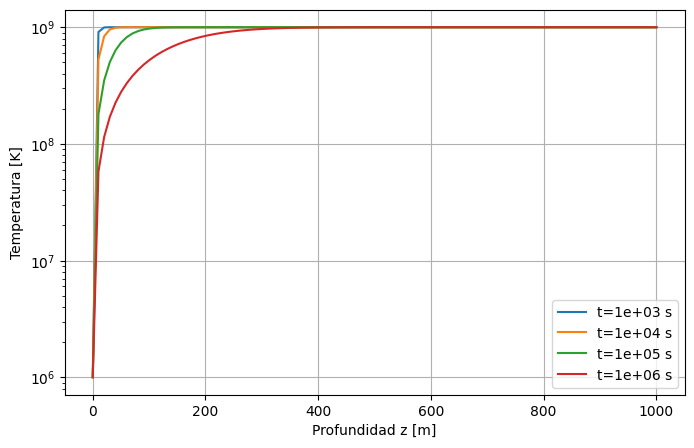

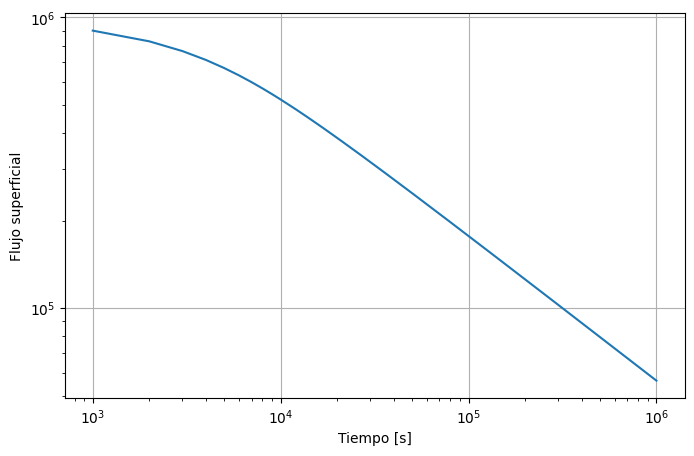

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMETROS FISICOS
L = 1.0e3
alpha = 1.0e-2
eps_nu = 1.0e-53
T_core = 1.0e9
T_surf = 1.0e6

t_max = 1.0e6
N = 100

dx = L/(N-1)

# ALGORITMO DE THOMAS

def thomas(a,b,c,d):

    n = len(d)

    cp = np.zeros(n-1)
    dp = np.zeros(n)
    x = np.zeros(n)

    cp[0] = c[0]/b[0]
    dp[0] = d[0]/b[0]

    for i in range(1,n-1):
        m = b[i] - a[i-1]*cp[i-1]
        cp[i] = c[i]/m
        dp[i] = (d[i] - a[i-1]*dp[i-1])/m

    m = b[n-1] - a[n-2]*cp[n-2]
    dp[n-1] = (d[n-1] - a[n-2]*dp[n-2])/m

    x[n-1] = dp[n-1]

    for i in range(n-2,-1,-1):
        x[i] = dp[i] - cp[i]*x[i+1]

    return x

# METODO EXPLICITO

def metodo_explicito(dt):

    lam = alpha*dt/dx**2
    n_steps = int(t_max/dt)

    T = np.ones(N)*T_core
    T[0] = T_surf

    tiempos_guardar = [1e3,1e4,1e5,1e6]

    historial = []
    flujo = []
    tiempos = []

    t = 0

    for step in range(n_steps):

        T_new = T.copy()

        for i in range(1,N-1):

            Qnu = eps_nu*T[i]**5

            T_new[i] = (
                T[i]
                + lam*(T[i+1]-2*T[i]+T[i-1])
                - dt*Qnu
            )

        T_new[0] = T_surf
        T_new[-1] = T_core

        T = T_new

        t += dt

        Fsurf = -alpha*(T[1]-T[0])/dx

        flujo.append(abs(Fsurf))
        tiempos.append(t)

        if np.isclose(t, tiempos_guardar).any():
            historial.append((t,T.copy()))

    return historial, tiempos, flujo


# METODO IMPLICITO

def metodo_implicito(dt):

    lam = alpha*dt/dx**2
    n_steps = int(t_max/dt)

    T = np.ones(N)*T_core
    T[0] = T_surf

    tiempos_guardar = [1e3,1e4,1e5,1e6]

    historial = []
    flujo = []
    tiempos = []

    nint = N-2

    a = -lam*np.ones(nint-1)
    b = (1+2*lam)*np.ones(nint)
    c = -lam*np.ones(nint-1)

    t = 0

    for step in range(n_steps):

        rhs = np.zeros(nint)

        for i in range(1,N-1):

            Qnu = eps_nu*T[i]**5

            rhs[i-1] = T[i] - dt*Qnu

        rhs[0] += lam*T_surf
        rhs[-1] += lam*T_core

        Tint = thomas(a,b,c,rhs)

        T[1:-1] = Tint

        T[0] = T_surf
        T[-1] = T_core

        t += dt

        Fsurf = -alpha*(T[1]-T[0])/dx

        flujo.append(abs(Fsurf))
        tiempos.append(t)

        if np.isclose(t, tiempos_guardar).any():
            historial.append((t,T.copy()))

    return historial, tiempos, flujo

# CRANK NICOLSON

def crank_nicolson(dt):

    lam = alpha*dt/dx**2
    n_steps = int(t_max/dt)

    T = np.ones(N)*T_core
    T[0] = T_surf

    tiempos_guardar = [1e3,1e4,1e5,1e6]

    historial = []
    flujo = []
    tiempos = []

    nint = N-2

    a = -(lam/2)*np.ones(nint-1)
    b = (1+lam)*np.ones(nint)
    c = -(lam/2)*np.ones(nint-1)

    t = 0

    for step in range(n_steps):

        rhs = np.zeros(nint)

        for i in range(1,N-1):

            Qnu = eps_nu*T[i]**5

            rhs[i-1] = (
                (lam/2)*T[i-1]
                + (1-lam)*T[i]
                + (lam/2)*T[i+1]
                - dt*Qnu
            )

        rhs[0] += (lam/2)*T_surf
        rhs[-1] += (lam/2)*T_core

        Tint = thomas(a,b,c,rhs)

        T[1:-1] = Tint

        T[0] = T_surf
        T[-1] = T_core

        t += dt

        Fsurf = -alpha*(T[1]-T[0])/dx

        flujo.append(abs(Fsurf))
        tiempos.append(t)

        if np.isclose(t, tiempos_guardar).any():
            historial.append((t,T.copy()))

    return historial, tiempos, flujo

# EJECUCION

hist_CN, t_CN, F_CN = crank_nicolson(1e3)

x = np.linspace(0,L,N)

plt.figure(figsize=(8,5))

for t, T in hist_CN:
    plt.plot(x,T,label=f't={t:.0e} s')

plt.xlabel('Profundidad z [m]')
plt.ylabel('Temperatura [K]')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.loglog(t_CN,F_CN)
plt.xlabel('Tiempo [s]')
plt.ylabel('Flujo superficial')
plt.grid()
plt.show()